In [1]:
from pathlib import Path
import xarray as xr
import numpy as np

folder = Path("/mnt/ceph/proj/WEKEO/S5P_PCA_V0.1")
files = list(folder.glob("S5P-PCA-BD7_*.nc"))
print(files)


ds = xr.open_dataset(files[0])

# print(ds)

[PosixPath('/mnt/ceph/proj/WEKEO/S5P_PCA_V0.1/S5P-PCA-BD7_2021-08-01_v0.1.nc'), PosixPath('/mnt/ceph/proj/WEKEO/S5P_PCA_V0.1/S5P-PCA-BD7_2021-08-06_v0.1.nc'), PosixPath('/mnt/ceph/proj/WEKEO/S5P_PCA_V0.1/S5P-PCA-BD7_2021-08-15_v0.1.nc')]


In [2]:
from wekeo_s5p_pca import processor

ds = processor.preprocess(ds=ds, min_detection=1, fill_value=-9999)

print(ds)

<xarray.Dataset> Size: 1GB
Dimensions:          (time: 14, scanline: 4173, ground_pixel: 215)
Coordinates:
  * time             (time) datetime64[ns] 112B 2021-08-01T00:26:08 ... 2021-...
  * scanline         (scanline) int16 8kB 0 1 2 3 4 ... 4168 4169 4170 4171 4172
  * ground_pixel     (ground_pixel) int16 430B 0 1 2 3 4 ... 210 211 212 213 214
Data variables: (12/21)
    latitude         (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    longitude        (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    cloud_fraction   (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    score_CO_1       (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    diag_CO_1        (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    score_CO_2       (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    ...               ...
    score_Surf_2     (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    diag_Surf_2      (time, scanl

In [3]:
from wekeo_s5p_pca import processor

ds = processor.accumulate_to_grid(ds, width=720)

print(ds)

/home/Joackim/projects/wekeo_s5p_pca/wekeo_s5p_pca/processor.py:120: RuntimeWarning: invalid value encountered in cast
  lat_idx = np.uint32(
/home/Joackim/projects/wekeo_s5p_pca/wekeo_s5p_pca/processor.py:124: RuntimeWarning: invalid value encountered in cast
  lon_idx = np.uint32(


<xarray.Dataset> Size: 17MB
Dimensions:               (latitude: 360, longitude: 720)
Coordinates:
  * latitude              (latitude) float64 3kB -90.0 -89.5 -89.0 ... 89.5 90.0
  * longitude             (longitude) float64 6kB -180.0 -179.5 ... 179.0 179.5
Data variables: (12/16)
    cloud_fraction_mean   (latitude, longitude) float32 1MB nan nan ... nan nan
    cloud_fraction_count  (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    score_CO_1_mean       (latitude, longitude) float32 1MB nan nan ... nan nan
    score_CO_1_count      (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    score_CO_2_mean       (latitude, longitude) float32 1MB nan nan ... nan nan
    score_CO_2_count      (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    ...                    ...
    diag_CO_2_mean        (latitude, longitude) float32 1MB nan nan ... nan nan
    diag_CO_2_count       (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    diag_CO_3_mean        (latitude, longitud

Figure saved to: plots/S5P_PCA_L3_20210801_mean_score_CO.png


(<Figure size 1600x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Mean Score Co\n(1787 non-zero pixels, 1787 valid pixels)'}>)

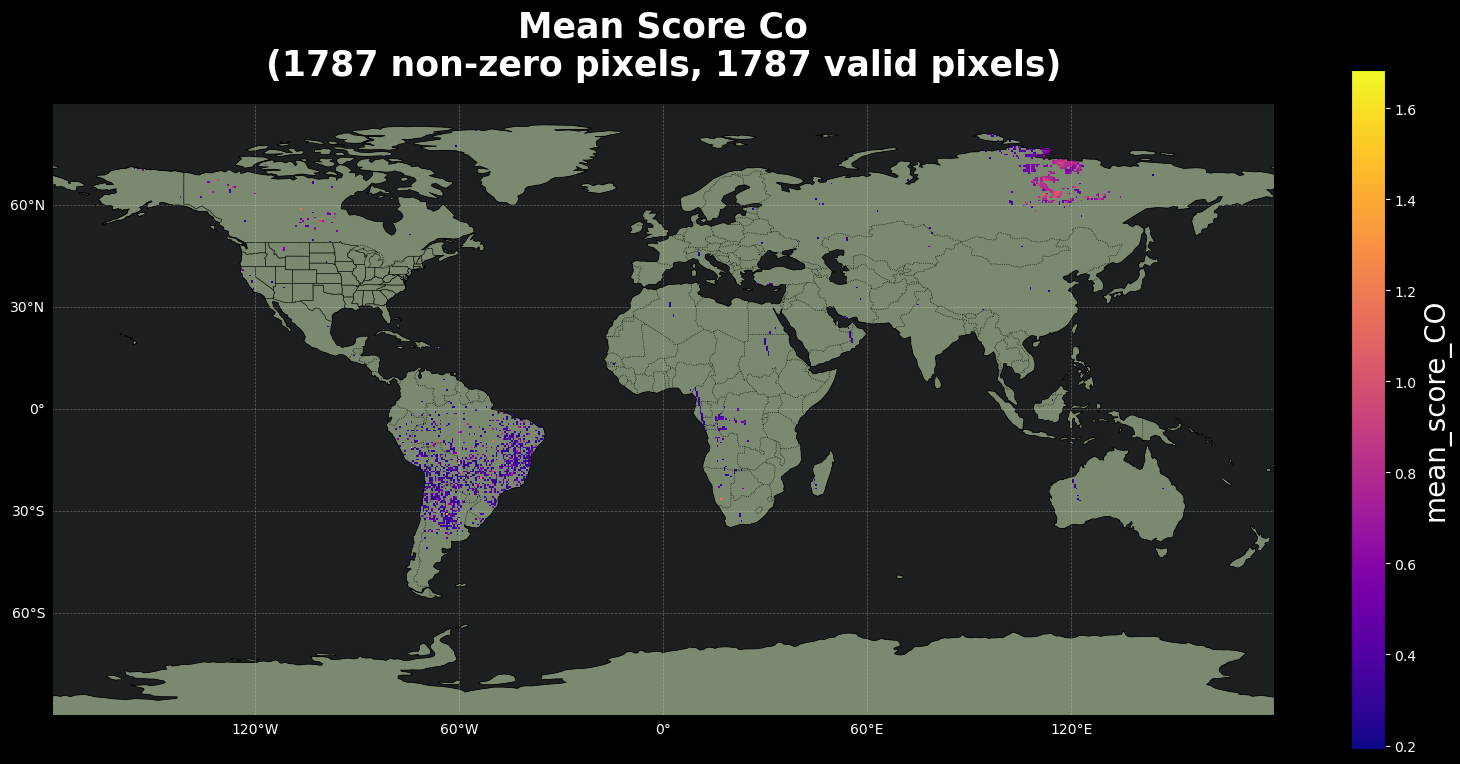

In [4]:
from wekeo_s5p_pca.plot_L3_s5p_pca import plot_L3_s5p_pca
from wekeo_s5p_pca import processor

ds = processor.postprocess(ds)

plot_L3_s5p_pca(
    ds, 
    variable='mean_score_CO',
    save_fig_dir='./plots'
)
